# User segmentations

Features:User_id, Subscription Type, Monthly Revenue, Join Date (or created_at), Last Payment Date, Country, Age, Gender, Device (number of devices) (we don't use User_id for the model, just write it here for connection)


 This notebook builds a Gold feature table for subscription churn prediction from existing Silver clean tables.

**Input tables**

- `silver.users`
- `silver.products`
- `silver.subscription_plans`
- `silver.subscriptions`
- `silver.subscription_changes`
- `silver.payments`
- `silver.license_keys`
- `silver.license_allocations`
- `silver.usage_events`
- `silver.support_tickets`

**Output table**

- `gold.churn_features`

The feature grain is one row per `subscription_id`. The label comes from the existing churn column in `silver.subscriptions`.

In [0]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from delta import configure_spark_with_delta_pip
from delta.tables import DeltaTable
from pyspark.sql.window import Window
from pyspark.sql.functions import col, row_number, to_timestamp, lit, create_map, upper, trim
from pyspark.sql.types import DecimalType
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from functools import reduce
from itertools import chain
import sklearn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
print(pyspark.__version__)

3.5.0


In [0]:
builder = (
    SparkSession.builder
    .appName("user_bronze")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
)

spark = configure_spark_with_delta_pip(
    builder,
    extra_packages=["org.postgresql:postgresql:42.7.3"]
).getOrCreate()

In [0]:
silver_db = "/Volumes/datalake_catalog/datalake_schema/silver_draft/"
gold_db = "gold"
# output_table = f"{gold_db}.churn_features"
snapshot_date = F.current_date()
cutoff_date =  F.current_date() #F.lit("2026-04-30").cast("date")

In [0]:
users = (
    spark.read
    .format("delta")
    .load(silver_db+"/users")
)
products = (
    spark.read
    .format("delta")
    .load(silver_db+"/products")
)
plans = (
    spark.read
    .format("delta")
    .load(silver_db+"/plans")
)
subs = (
    spark.read
    .format("delta")
    .load(silver_db+"/subscriptions")
)
changes = (
    spark.read
    .format("delta")
    .load(silver_db+"/subscription_changes")
)
payments = (
    spark.read
    .format("delta")
    .load(silver_db+"/payments")
)
licenses = (
    spark.read
    .format("delta")
    .load(silver_db+"/licenses")
)
allocations = (
    spark.read
    .format("delta")
    .load(silver_db+"/license_allocations")
)
usage = (
    spark.read
    .format("delta")
    .load(silver_db+"/usage_events")
)
tickets = (
    spark.read
    .format("delta")
    .load(silver_db+"/support_tickets")
)

In [0]:
plans.show(20)

+----------+---+-------+----------+-------------+------+--------+-------------------+--------------------+--------------------+--------------------+
|product_id| id|plan_id|      tier|billing_cycle| price|currency|         created_at|         ingest_time|   source_identifier|            batch_id|
+----------+---+-------+----------+-------------+------+--------+-------------------+--------------------+--------------------+--------------------+
|         1|  1|      1|  Standard|       annual| 15.77|     USD|2023-01-04 00:00:00|2026-04-22 04:31:...|jdbc:postgresql:/...|app-2026042204293...|
|         1|  3|      2|     Basic|      monthly| 10.40|     VND|2023-05-23 00:00:00|2026-04-22 04:31:...|jdbc:postgresql:/...|app-2026042204293...|
|         2|  4|      3|Enterprise|      monthly|370.16|     USD|2023-01-16 00:00:00|2026-04-22 04:31:...|jdbc:postgresql:/...|app-2026042204293...|
|         2|  5|      4|   Premium|      monthly| 41.87|     USD|2022-09-16 00:00:00|2026-04-22 04:31:...|

In [0]:
plans.select("tier").distinct().show()

+----------+
|      tier|
+----------+
|   Premium|
|Free Trial|
|     Basic|
|  Standard|
|Enterprise|
+----------+



## Subscription Type

In [0]:
# user_plan_ohe = (
#     subs
#     .select("user_id", "plan_id")
#     .dropna(subset=["user_id", "plan_id"])
#     .distinct()   # Avoid duplicate user_id-plan_id pairs
#     .withColumn("value", F.lit(1))
#     .groupBy("user_id")
#     .pivot("plan_id")
#     .agg(F.max("value"))   # or F.first("value")
#     .fillna(0)
# )

# user_plan_ohe.show()
user_plan_ohe = (
    subs.alias("s")
    .select("user_id", "plan_id")
    .dropna(subset=["user_id", "plan_id"])
    .distinct()   # avoid duplicate user-plan pairs
    .join(
        plans.select("plan_id", "tier", "billing_cycle").dropna(subset=["plan_id", "tier"]).distinct().alias("p"),
        on="plan_id",
        how="left"
    )
    .withColumn("tier", F.trim(F.col("tier")))
    .groupBy("user_id")
    .agg(
        F.countDistinct("plan_id").alias("num_distinct_plans"),
        F.max(F.when(F.col("tier") == "Premium", 1).otherwise(0)).alias("has_premium"),
        F.max(F.when(F.col("tier") == "Free Trial", 1).otherwise(0)).alias("has_free_trial"),
        F.max(F.when(F.col("tier") == "Basic", 1).otherwise(0)).alias("has_basic"),
        F.max(F.when(F.col("tier") == "Enterprise", 1).otherwise(0)).alias("has_enterprise_plan"),
        F.max(F.when(F.col("tier") == "Standard", 1).otherwise(0)).alias("has_standard"),
        F.max(F.when(F.col("billing_cycle") == "annual", 1).otherwise(0)).alias("has_annual"),
        F.max(F.when(F.col("billing_cycle") == "monthly", 1).otherwise(0)).alias("has_monthly")
    )
)

user_plan_ohe.show()

+-------+------------------+-----------+--------------+---------+-------------------+------------+----------+-----------+
|user_id|num_distinct_plans|has_premium|has_free_trial|has_basic|has_enterprise_plan|has_standard|has_annual|has_monthly|
+-------+------------------+-----------+--------------+---------+-------------------+------------+----------+-----------+
|  16983|                 3|          0|             0|        1|                  0|           1|         1|          1|
|   7925|                 7|          1|             0|        1|                  1|           1|         1|          1|
|  46938|                 4|          0|             0|        1|                  1|           1|         1|          1|
|  41955|                 3|          1|             0|        1|                  1|           0|         1|          1|
|   8674|                 6|          1|             0|        1|                  0|           1|         1|          1|
|  13867|               

In [0]:
# df1 = users.join(user_plan_ohe, on="user_id", how="left")
# df1.show(2)
# ohe_cols = [str(i) for i in range(1, 21)]
df1 = (
    users
    .join(user_plan_ohe, on="user_id", how="left")
    .fillna(0)
)

In [0]:
# df1.show()

In [0]:
# df1.select([
#     F.count(F.when(F.col(c).isNull(), 1)).alias(c)
#     for c in df1.columns
# ]).show()


## Monthly_revenue

avg_monthly_revenue = average revenue per user across the full observation window (from user created their account till the cutoff date).
total successful revenue up to cutoff_date / number of months from user.created_at to cutoff_date

In [0]:
payments.select("payment_status").distinct().show()

+--------------+
|payment_status|
+--------------+
|       success|
|      refunded|
|        failed|
+--------------+



In [0]:
df1.show(1)

+-------+----------+----------+--------------------+-------+---+------+-------------------+-------------+-------------------+--------------------+----------------+------------------+-----------+--------------+---------+-------------------+------------+----------+-----------+
|user_id|first_name| last_name|               email|country|age|gender|acquisition_channel|is_enterprise|         created_at|         ingest_time|is_valid_country|num_distinct_plans|has_premium|has_free_trial|has_basic|has_enterprise_plan|has_standard|has_annual|has_monthly|
+-------+----------+----------+--------------------+-------+---+------+-------------------+-------------+-------------------+--------------------+----------------+------------------+-----------+--------------+---------+-------------------+------------+----------+-----------+
|     11|    Rajata|Srivastava|rajata.srivastava...|  India| 44|  male|               paid|        false|2024-11-09 22:34:36|2026-04-22 04:25:...|            true|         

In [0]:
# 1) Total successful revenue per user up to cutoff_date
user_total_revenue = (
    payments.alias("p")
    .filter(
        (F.col("payment_status") == "success") &
        F.col("payment_date").isNotNull() &
        (F.to_date("payment_date") <= cutoff_date)
    )
    .join(
        subs.select("subscription_id", "user_id").alias("s"),
        on="subscription_id",
        how="left"
    )
    .groupBy("user_id")
    .agg(
        F.sum("amount").alias("total_revenue")
    )
)

# 2) Number of months from user created_at to cutoff_date (inclusive)
user_active_months = (
    df1
    .filter(F.col("created_at").isNotNull())
    .withColumn("created_month", F.trunc(F.to_date("created_at"), "month"))
    .withColumn("cutoff_month", F.trunc(cutoff_date, "month"))
    .withColumn(
        "active_months",
        F.greatest(
            F.lit(1),
            F.floor(F.months_between(F.col("cutoff_month"), F.col("created_month"))) + F.lit(1)
        )
    )
)

# 3) Avg monthly revenue = total_revenue / active_months
df2 = (
    user_active_months.alias("u")
    .join(user_total_revenue.alias("r"), on="user_id", how="left")
    .fillna({"total_revenue": 0})
    .withColumn(
        "avg_monthly_revenue",
        F.col("total_revenue") / F.col("active_months")
    )
    .orderBy("user_id")
)

df2.show(1, False)

+-------+----------+---------+-----------------------+-------+---+------+-------------------+-------------+-------------------+--------------------------+----------------+------------------+-----------+--------------+---------+-------------------+------------+----------+-----------+-------------+------------+-------------+-------------+-----------------------+
|user_id|first_name|last_name|email                  |country|age|gender|acquisition_channel|is_enterprise|created_at         |ingest_time               |is_valid_country|num_distinct_plans|has_premium|has_free_trial|has_basic|has_enterprise_plan|has_standard|has_annual|has_monthly|created_month|cutoff_month|active_months|total_revenue|avg_monthly_revenue    |
+-------+----------+---------+-----------------------+-------+---+------+-------------------+-------------+-------------------+--------------------------+----------------+------------------+-----------+--------------+---------+-------------------+------------+----------+---

In [0]:
df2.count()

50000

## Join_date => this is the created_at

## Last_payment_date

In [0]:
last_payment_date = (
    payments.alias("p")
    .join(
        subs.select("subscription_id", "user_id").alias("s"),
        on="subscription_id",
        how="left"
    )
    .filter(
        F.col("payment_date").isNotNull() &
        (F.to_date("payment_date") <= cutoff_date)   # remove this line if you do not want cutoff filtering
    )
    .groupBy("user_id")
    .agg(
        F.max("payment_date").alias("last_payment_date")
    )
)

df3 = (
    df2.alias("u")
    .join(last_payment_date.alias("l"), on="user_id", how="left")
)

df3.show(1, False)


+-------+----------+----------+---------------------------+-------+---+------+-------------------+-------------+-------------------+--------------------------+----------------+------------------+-----------+--------------+---------+-------------------+------------+----------+-----------+-------------+------------+-------------+-------------+-----------------------+-------------------+
|user_id|first_name|last_name |email                      |country|age|gender|acquisition_channel|is_enterprise|created_at         |ingest_time               |is_valid_country|num_distinct_plans|has_premium|has_free_trial|has_basic|has_enterprise_plan|has_standard|has_annual|has_monthly|created_month|cutoff_month|active_months|total_revenue|avg_monthly_revenue    |last_payment_date  |
+-------+----------+----------+---------------------------+-------+---+------+-------------------+-------------+-------------------+--------------------------+----------------+------------------+-----------+--------------+--

In [0]:
df3.count()

50000

## Country

## Age

## Gender

## Device

In [0]:
user_device_count = (
    usage.alias("e")   # replace "usage" with your actual dataframe name
    .filter(
        F.col("user_id").isNotNull() &
        F.col("device_type").isNotNull() &
        (F.to_date("event_timestamp") <= cutoff_date)
    )
    .groupBy("user_id")
    .agg(
        F.countDistinct("device_type").alias("device_count")
    )
)

df4 = (
    df3.alias("u")
    .join(user_device_count.alias("d"), on="user_id", how="left")
    .fillna({"device_count": 0})
)

In [0]:
df4.count()

50000

## Features for clustering

Subscription Type (one-hot), Monthly Revenue, Join Date (or created_at), Country, Age, Gender, Device (number of devices), acquisition_channel, is_enterprise, total_revenue, last_payment_date, device_count;  Convert all 3 columns to numeric (days-based features) for the timestamp.

In [0]:
df5 = df4.drop("user_id", "first_name", "last_name", "email", "created_month", "ingest_time" ,"is_valid_country", "cutoff_month", "active_months")
df5.count()

50000

In [0]:
df5.columns

['country',
 'age',
 'gender',
 'acquisition_channel',
 'is_enterprise',
 'created_at',
 'num_distinct_plans',
 'has_premium',
 'has_free_trial',
 'has_basic',
 'has_enterprise_plan',
 'has_standard',
 'has_annual',
 'has_monthly',
 'total_revenue',
 'avg_monthly_revenue',
 'last_payment_date',
 'device_count']

## Algorithms

### Visualize all components in 2d

In [0]:
df6 = (
    df5
    # tenure from created_at
    .withColumn(
        "tenure_days",
        F.datediff(cutoff_date, F.col("created_at"))
    )
    # recency from last payment
    .withColumn(
        "days_since_last_payment",
        F.datediff(cutoff_date, F.col("last_payment_date"))
    )
    # drop original date/timestamp columns
    .drop(
        "created_at",
        "last_payment_date"
    )
)
df6.show(2)

+-------+---+------+-------------------+-------------+------------------+-----------+--------------+---------+-------------------+------------+----------+-----------+-------------+--------------------+------------+-----------+-----------------------+
|country|age|gender|acquisition_channel|is_enterprise|num_distinct_plans|has_premium|has_free_trial|has_basic|has_enterprise_plan|has_standard|has_annual|has_monthly|total_revenue| avg_monthly_revenue|device_count|tenure_days|days_since_last_payment|
+-------+---+------+-------------------+-------------+------------------+-----------+--------------+---------+-------------------+------------+----------+-----------+-------------+--------------------+------------+-----------+-----------------------+
|  Other| 29|  male|           referral|         true|                 3|          1|             0|        1|                  0|           1|         0|          1|       232.24|7.491612903225806...|           0|        911|                    6

In [0]:
df6.columns

['country',
 'age',
 'gender',
 'acquisition_channel',
 'is_enterprise',
 'num_distinct_plans',
 'has_premium',
 'has_free_trial',
 'has_basic',
 'has_enterprise_plan',
 'has_standard',
 'has_annual',
 'has_monthly',
 'total_revenue',
 'avg_monthly_revenue',
 'device_count',
 'tenure_days',
 'days_since_last_payment']

## Clustering

In [0]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [0]:
pdf = df6.toPandas()

In [0]:
pdf.columns

Index(['country', 'age', 'gender', 'acquisition_channel', 'is_enterprise',
       'num_distinct_plans', 'has_premium', 'has_free_trial', 'has_basic',
       'has_enterprise_plan', 'has_standard', 'has_annual', 'has_monthly',
       'total_revenue', 'avg_monthly_revenue', 'device_count', 'tenure_days',
       'days_since_last_payment'],
      dtype='object')

In [0]:
pdf.head()

,country,age,gender,acquisition_channel,is_enterprise,num_distinct_plans,has_premium,has_free_trial,has_basic,has_enterprise_plan,has_standard,has_annual,has_monthly,total_revenue,avg_monthly_revenue,device_count,tenure_days,days_since_last_payment
0,Germany,38,male,organic,False,4,1,0,1,0,1,0,1,248.54,6.37282051282051282051,0,1174,862.0
1,Other,50,male,organic,False,5,1,0,1,1,1,0,1,982.90,26.56486486486486486486,0,1124,840.0
2,Brazil,18,male,paid,False,5,1,0,1,0,1,1,1,648.85,36.04722222222222222222,0,539,304.0
3,Other,34,other,referral,False,4,1,0,1,1,0,0,1,2697.14,385.30571428571428571429,0,202,47.0
4,Other,42,male,referral,False,7,1,0,1,1,1,1,1,2976.55,119.06200000000000000000,0,731,439.0


In [0]:
# Categorical variables
categorical = ['country', 'gender', 'acquisition_channel', 'is_enterprise']

# One-hot encode categorical columns
df_seg = pd.get_dummies(
    pdf,
    columns=categorical,
    prefix=categorical,
    prefix_sep='=',
    dtype='int'
)

# df_seg is now ready for segmentation algorithm
print(df_seg.head())
print(df_seg.shape)


   age  num_distinct_plans  ...  is_enterprise=False  is_enterprise=True
0   38                   4  ...                    1                   0
1   50                   5  ...                    1                   0
2   18                   5  ...                    1                   0
3   34                   4  ...                    1                   0
4   42                   7  ...                    1                   0

[5 rows x 33 columns]
(50000, 33)


In [0]:
df_seg.columns

Index(['age', 'num_distinct_plans', 'has_premium', 'has_free_trial',
       'has_basic', 'has_enterprise_plan', 'has_standard', 'has_annual',
       'has_monthly', 'total_revenue', 'avg_monthly_revenue', 'device_count',
       'tenure_days', 'days_since_last_payment', 'country=Australia',
       'country=Brazil', 'country=Canada', 'country=France', 'country=Germany',
       'country=India', 'country=Japan', 'country=Other', 'country=Singapore',
       'country=Spain', 'country=Vietnam', 'gender=female', 'gender=male',
       'gender=other', 'acquisition_channel=organic',
       'acquisition_channel=paid', 'acquisition_channel=referral',
       'is_enterprise=False', 'is_enterprise=True'],
      dtype='object')

In [0]:
#Lựa chọn các đặc trưng cho clustering
X = df_seg.dropna()
#Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f10d17ec160>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

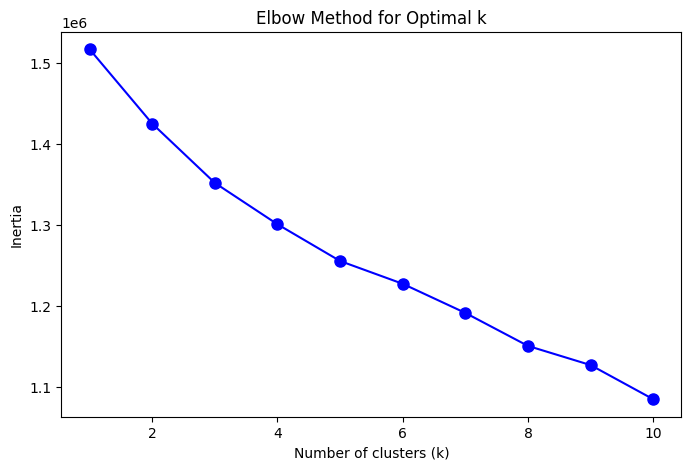

In [0]:
#Sử dụng Elbow Method để tìm số lượng cụm tối ưu
inertia = []
K = range(1, 11)

for k in K:
  kmeans = KMeans(n_clusters=k, random_state=2001)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

# Vẽ đồ thị Elbow
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [0]:
optimal_k=4

### Comment:
From k = 1 to 6, inertia decreases quite a lot.
After k = 6, the curve starts to flatten more, meaning adding more clusters gives smaller improvement.
There is no very sharp elbow in this plot, but k = 6 looks like the most reasonable “bend” where the rate of improvement starts slowing down.

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f10d1401240>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

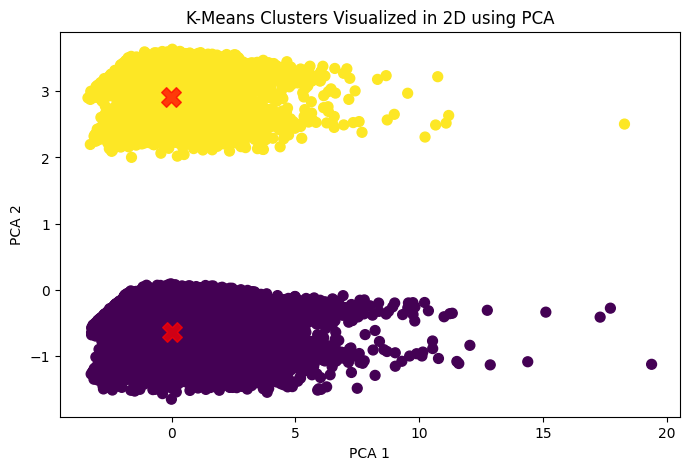

In [0]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# KMeans on full feature space
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=2001, n_init=10)
y_kmeans = kmeans.fit_predict(X_scaled)

# Reduce 35D -> 2D for visualization
pca = PCA(n_components=2, random_state=2001)
X_2d = pca.fit_transform(X_scaled)

# Project cluster centers from 35D -> 2D
centers_2d = pca.transform(kmeans.cluster_centers_)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c='red', s=200, alpha=0.75, marker='X')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clusters Visualized in 2D using PCA')
plt.show()


In [0]:
# PCA analysis

print("Explained variance ratio of PC1 and PC2:", pca.explained_variance_ratio_)
print("Total explained variance by 2 PCs:", pca.explained_variance_ratio_.sum())


Explained variance ratio of PC1 and PC2: [0.07848273 0.06074275]
Total explained variance by 2 PCs: 0.13922547831857687


PCs for 50% variance: 10
PCs for 70% variance: 16
PCs for 80% variance: 20


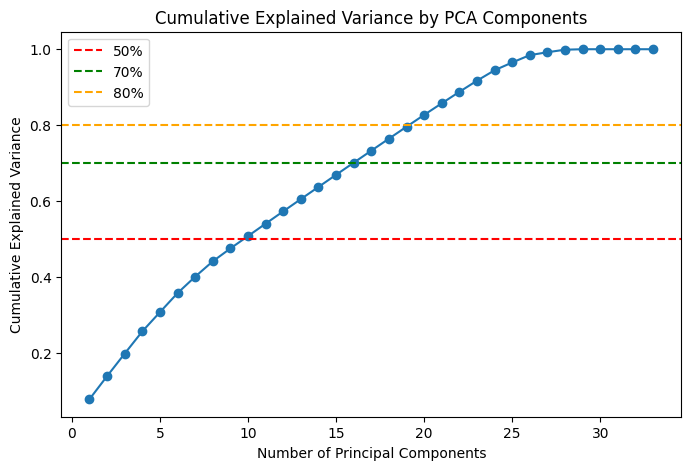

In [0]:
# from sklearn.decomposition import PCA
# import numpy as np
# import matplotlib.pyplot as plt

pca_full = PCA(random_state=2001)
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

print("PCs for 50% variance:", np.argmax(cum_var >= 0.50) + 1)
print("PCs for 70% variance:", np.argmax(cum_var >= 0.70) + 1)
print("PCs for 80% variance:", np.argmax(cum_var >= 0.80) + 1)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.5, color='red', linestyle='--', label='50%')
plt.axhline(0.7, color='green', linestyle='--', label='70%')
plt.axhline(0.8, color='orange', linestyle='--', label='80%')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.legend()
plt.show()

### Comment:
The analysis indicates that the customer base can be meaningfully segmented into two major behavioural groups, with the six-cluster model providing a more granular view of customer differences within those broader segments. While some overlap remains between individual clusters, the model offers a practical and actionable framework for identifying distinct customer profiles, supporting more targeted decision-making across areas such as engagement strategy, retention, and product positioning.

## Clustering with K-means with Silhouette

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f10d1472e60>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

Average silhouette score: 0.103334914561841


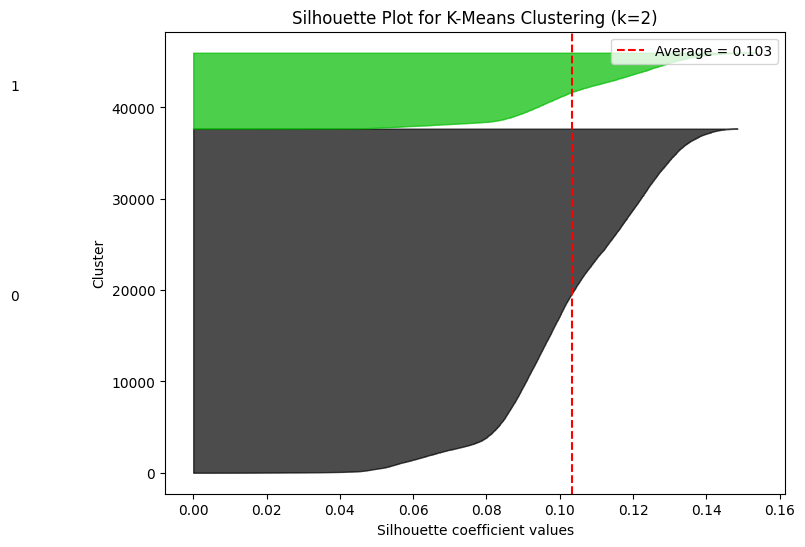

In [0]:
# KMeans on full scaled dataset
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=2001, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Average silhouette score
silhouette_avg = silhouette_score(X_scaled, labels)
print("Average silhouette score:", silhouette_avg)

# Silhouette value for each sample
sample_silhouette_values = silhouette_samples(X_scaled, labels)

# Plot
fig, ax1 = plt.subplots(figsize=(8, 6))

y_lower = 10
for i in range(optimal_k):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.nipy_spectral(float(i) / optimal_k)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7
    )

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.set_title(f"Silhouette Plot for K-Means Clustering (k={optimal_k})")
ax1.set_xlabel("Silhouette coefficient values")
ax1.set_ylabel("Cluster")

ax1.axvline(x=silhouette_avg, color="red", linestyle="--", label=f"Average = {silhouette_avg:.3f}")
ax1.legend()

plt.show()

### Comments:
The business value of this clustering is that it turns a broad user base into distinct customer groups that can be managed differently. Using demographic, acquisition, product, billing, revenue, and lifecycle features, we can identify which segments are higher value, more likely to upgrade, more at risk of churn, or better suited to specific pricing and engagement strategies. This supports more targeted marketing, smarter retention actions, better packaging and pricing decisions, and more focused product investment

## To test which k is best

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f10d13ce290>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

k=2, silhouette score=0.1033


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f10d13cea70>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

k=3, silhouette score=0.0731


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f10d13ce4d0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

...

k=8, silhouette score=0.0988


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f10d13cd5a0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

k=9, silhouette score=0.0897


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f10d13cd5a0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

k=10, silhouette score=0.1194


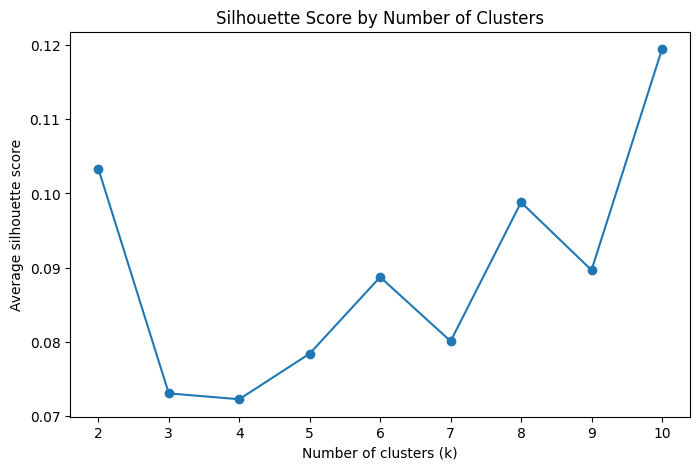

In [0]:
k_values = range(2, 11)
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=2001, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"k={k}, silhouette score={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

### Comments:
The highest silhouette is at K = 10, but not choose 10 just because it is numerically highest. The elbow method is intended to find the point where adding clusters starts giving only diminishing returns, and the elbow curve does not show a compelling case for 9 or 10. In fact, the elbow guidance says the best K is typically the inflection point, not simply the largest K tested. Also, authoritative references note that if the elbow is smooth or weak, the clustering structure may itself be weak or ambiguous.

Because if the two groups truly differ in revenue, product usage, and churn risk, then treating them the same costs money. It can lead to the wrong offer for the wrong customer, wasted marketing budget, weaker retention efforts, and product decisions that are too generic. Segmentation helps businesses focus on the most valuable groups, personalise engagement, optimise pricing and packaging, and allocate resources more effectively.

## Using the segmentation

In [0]:
X.columns

Index(['age', 'num_distinct_plans', 'has_premium', 'has_free_trial',
       'has_basic', 'has_enterprise_plan', 'has_standard', 'has_annual',
       'has_monthly', 'total_revenue', 'avg_monthly_revenue', 'device_count',
       'tenure_days', 'days_since_last_payment', 'country=Australia',
       'country=Brazil', 'country=Canada', 'country=France', 'country=Germany',
       'country=India', 'country=Japan', 'country=Other', 'country=Singapore',
       'country=Spain', 'country=Vietnam', 'gender=female', 'gender=male',
       'gender=other', 'acquisition_channel=organic',
       'acquisition_channel=paid', 'acquisition_channel=referral',
       'is_enterprise=False', 'is_enterprise=True'],
      dtype='object')

In [0]:
# 1) Attach cluster labels
df_clustered = X.copy()
df_clustered["cluster"] = y_kmeans

# 2) Column groups
numeric_cols = [
    "age",
    "num_distinct_plans",
    "total_revenue",
    "avg_monthly_revenue",
    "device_count",
    "tenure_days",
    "days_since_last_payment"
]

binary_cols = [
    "has_premium",
    "has_free_trial",
    "has_basic",
    "has_enterprise_plan",
    "has_standard",
    "has_annual",
    "has_monthly",
    "is_enterprise=True"   # only use True; False is redundant
]

country_cols = [c for c in df_clustered.columns if c.startswith("country=")]
gender_cols = [c for c in df_clustered.columns if c.startswith("gender=")]
channel_cols = [c for c in df_clustered.columns if c.startswith("acquisition_channel=")]

# 3) Main profile table
profile = (
    df_clustered
    .groupby("cluster")[numeric_cols + binary_cols]
    .mean()
    .round(3)
)

# Add size
profile["user_count"] = df_clustered.groupby("cluster").size()
profile["user_pct"] = (profile["user_count"] / len(df_clustered)).round(3)

print("=== Main cluster profile ===")
print(profile)

# 4) Compare each cluster to overall average
overall_avg = df_clustered[numeric_cols + binary_cols].mean()

diff_vs_overall = (profile[numeric_cols + binary_cols] - overall_avg).round(3)

print("\n=== Difference vs overall average ===")
print(diff_vs_overall)

# 5) Top dominant country / gender / acquisition channel in each cluster
def get_top_category(df, cols, cluster_col="cluster"):
    if not cols:
        return None
    tmp = df.groupby(cluster_col)[cols].mean()
    return pd.DataFrame({
        "top_category": tmp.idxmax(axis=1),
        "top_pct": tmp.max(axis=1).round(3)
    })

country_top = get_top_category(df_clustered, country_cols)
gender_top = get_top_category(df_clustered, gender_cols)
channel_top = get_top_category(df_clustered, channel_cols)

print("\n=== Top country by cluster ===")
print(country_top)

print("\n=== Top gender by cluster ===")
print(gender_top)

print("\n=== Top acquisition channel by cluster ===")
print(channel_top)

/home/spark-380cb340-d52e-465c-9016-5b/.ipykernel/2917/command-8885330999335851-2874764777:35: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  .mean()


=== Main cluster profile ===
            age  num_distinct_plans  ...  user_count  user_pct
cluster                              ...                      
0        36.536               4.134  ...       37666     0.819
1        36.629               4.132  ...        8304     0.181

[2 rows x 15 columns]


---------------------------------------------------------------------------
KeyError                                  Traceback (most recent call last)
File <command-8885330999335851>, line 49
     46 # 4) Compare each cluster to overall average
     47 overall_avg = df_clustered[numeric_cols + binary_cols].mean()
---> 49 diff_vs_overall = (profile[numeric_cols + binary_cols] - overall_avg).round(3)
     51 print("\n=== Difference vs overall average ===")
     52 print(diff_vs_overall)

File /databricks/python/lib/python3.10/site-packages/pandas/core/frame.py:3813, in DataFrame.__getitem__(self, key)
   3811     if is_iterator(key):
   3812         key = list(key)
-> 3813     indexer = self.columns._get_indexer_strict(key, "columns")[1]
   3815 # take() does not accept boolean indexers
   3816 if getattr(indexer, "dtype", None) == bool:

File /databricks/python/lib/python3.10/site-packages/pandas/core/indexes/base.py:6070, in Index._get_indexer_strict(self, key, axis_name)
   6067 else

## Report
## Report for Team Leader
The clustering result shows that the two segments are not broadly different across most behavioural or commercial variables. Average age, number of distinct plans, total revenue, average monthly revenue, device count, tenure, days since last payment, plan mix, country mix, gender mix, and acquisition channel are all very close between the two clusters. The main structural difference is that Cluster 0 consists entirely of enterprise users (is_enterprise=True = 1.0), while Cluster 1 consists entirely of non-enterprise users (is_enterprise=True = 0.0). This indicates that the K-Means model has primarily learned to separate users based on the enterprise flag rather than discovering deeper behavioural segments.
From a business interpretation perspective, Cluster 0 can be described as an Enterprise Customer Segment, and Cluster 1 as a Non-Enterprise Customer Segment. However, beyond enterprise status, the two groups are only marginally different. Cluster 1 is slightly higher in total revenue, average monthly revenue, tenure, and enterprise-plan adoption, while Cluster 0 is slightly higher in basic-plan share and monthly share, but these gaps are very small and not strong enough to support rich behavioural differentiation. In practical terms, this means the current segmentation is valid as a customer-type split, but weak as a behavioural/value segmentation.
The implication is that the current feature set — especially the inclusion of the strong binary indicator is_enterprise=True / False — is dominating the clustering outcome. If the goal is to identify more meaningful usage or value-based customer personas, the next step should be to rerun segmentation without the enterprise flag, or alternatively build separate segmentations for enterprise and non-enterprise users. That would help determine whether there are additional subgroups based on revenue, plan adoption, billing commitment, product usage, or payment behaviour rather than simply company type.

## Report for Stakeholders
The analysis shows that our customer base is currently being divided into two very clear groups: enterprise customers and non-enterprise customers. In other words, the strongest difference in the data is not spending, tenure, or usage behaviour — it is whether the customer is classified as enterprise or not. This means the segmentation is useful for confirming that enterprise and non-enterprise customers should be treated as two distinct customer groups.
At the same time, the two groups are otherwise very similar on most of the other measures we tested, including revenue, number of plans, product usage, tenure, payment recency, country mix, gender mix, and acquisition channel. So, while the model successfully identifies two groups, the current result does not yet reveal deeply different behavioural profiles beyond customer type. Put simply, the segmentation is telling us more about who the customers are than how differently they behave.
From a business point of view, this gives us a useful starting point: we can treat enterprise customers and non-enterprise customers as two separate strategic groups. However, if we want more actionable segments — for example, groups based on churn risk, upsell potential, or product adoption depth — we will need a second round of analysis focused more on behavioural and commercial patterns rather than enterprise classification alone.

## Short naming of the two clusters:

Cluster 0: Enterprise Customers

Cluster 1: Non-Enterprise Customers